# Distancia de Hamming: detectar no es lo mismo que corregir

**Tema 3 · Apartados 3.1–3.2 · Demostración orientativa: 8–15 minutos.**

Examinar el código (5, 2) de la teoría y relacionar su distancia mínima con las garantías de detección y corrección.

## Cómo experimentar

Ejecuta todo de arriba abajo. Cambia un parámetro, predice qué ocurrirá
y vuelve a ejecutar todas las celdas. En Jupyter: *Kernel → Restart Kernel and Run All Cells*;
en Colab: *Entorno de ejecución → Ejecutar todas*.

La vista HTML muestra los resultados guardados. Para recalcular se utiliza este cuaderno.
Los comentarios `#@param` permiten formularios en Colab; en Jupyter puedes editar los valores.
No se necesitan datos externos ni otros cuadernos. Las figuras y cálculos son deterministas.

## Modelo y pregunta

Usamos exactamente las cuatro palabras ya dadas en la teoría:
$$\mathcal C=\{00000,\ 00111,\ 11100,\ 11011\}.$$
Hay $2^2$ palabras de longitud 5: $k=2$, $n=5$ y $R_c=2/5$.
La distancia de Hamming cuenta las posiciones en las que dos palabras difieren.
$d_{\min}$ es la menor distancia entre **palabras distintas** del código.

Como detector se garantizan hasta $d_{\min}-1$ errores. Como corrector se garantizan
hasta $t=\lfloor(d_{\min}-1)/2\rfloor$ errores. Son dos formas de utilizar el código:
no significa que un corrector avise siempre cuando hay más de $t$ errores.

Solo compararemos palabras ya escritas. No generamos palabras a partir de mensajes
ni implementamos un decodificador.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 3.8), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## Parámetros

Modifica un valor cada vez. Los comentarios indican unidades y rangos.

In [2]:
#@title Parámetros
palabra_a = "00000" #@param ["00000", "00111", "11100", "11011"]
palabra_b = "00111" #@param ["00000", "00111", "11100", "11011"]
palabras = ["00000", "00111", "11100", "11011"]
assert palabra_a in palabras and palabra_b in palabras

## 1. Contar las diferencias

Compara primero las dos filas a simple vista. Las columnas naranjas contienen bits
distintos. Si eliges dos veces la misma palabra, la distancia es cero, pero ese par
no interviene en el cálculo de la distancia mínima.

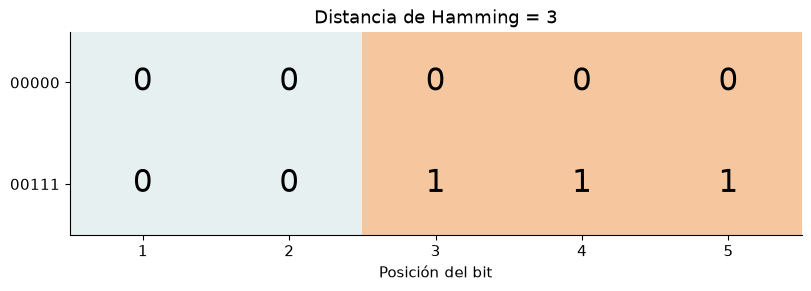

In [3]:
from matplotlib.colors import ListedColormap
a = np.array(list(palabra_a),dtype=int)
b = np.array(list(palabra_b),dtype=int)
distintas = a != b
distancia = int(distintas.sum())
fig, ax = plt.subplots(figsize=(8,2.8),layout="constrained")
ax.imshow(np.tile(distintas,(2,1)),cmap=ListedColormap(["#e7f0f1","#f6c79f"]),vmin=0,vmax=1,aspect="auto")
for fila,bits in enumerate([a,b]):
    for columna,bit in enumerate(bits):
        ax.text(columna,fila,str(bit),ha="center",va="center",fontsize=22)
ax.set(xticks=range(5),xticklabels=range(1,6),yticks=[0,1],yticklabels=[palabra_a,palabra_b],
       xlabel="Posición del bit",title=f"Distancia de Hamming = {distancia}")
plt.show()

## 2. La distancia mínima es una propiedad del código completo

Ahora comparamos cada pareja de palabras. La diagonal es cero porque compara
cada palabra consigo misma; la excluimos. La distancia de una pareja concreta
puede ser mayor que $d_{\min}$, pero las garantías generales dependen del menor valor.

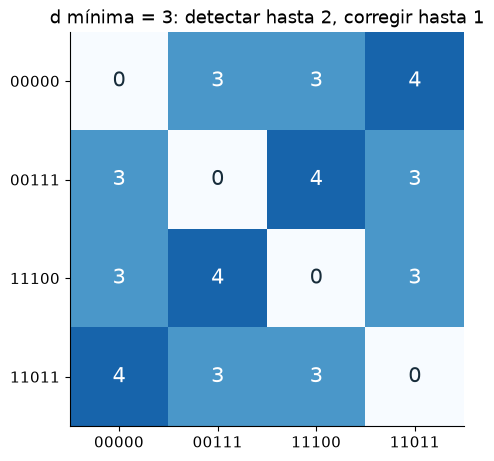

R = 2/5 = 0.4; d mínima = 3; t = 1.


In [4]:
bits = np.array([list(p) for p in palabras],dtype=int)
distancias = np.sum(bits[:,None,:] != bits[None,:,:],axis=2)
d_min = int(distancias[~np.eye(4,dtype=bool)].min())
detectables = d_min-1
corregibles = (d_min-1)//2
fig, ax = plt.subplots(figsize=(6.4,4.5),layout="constrained")
ax.imshow(distancias,cmap="Blues",vmin=0,vmax=5)
for i in range(4):
    for j in range(4):
        ax.text(j,i,str(distancias[i,j]),ha="center",va="center",
                color="white" if distancias[i,j] >= 3 else "#172c3a",fontsize=15)
ax.set(xticks=range(4),xticklabels=palabras,yticks=range(4),yticklabels=palabras,
       title=f"d mínima = {d_min}: detectar hasta {detectables}, corregir hasta {corregibles}")
plt.show()
print(f"R = 2/5 = {2/5:.1f}; d mínima = {d_min}; t = {corregibles}.")

## Antes de mirar la explicación

Partimos de la palabra transmitida **00000**. Responde a mano:

1. Se recibe **00001**: ¿a qué distancia está de 00000? ¿Puede haber otra palabra válida a distancia uno?
2. Se recibe **00110**: ¿es una palabra válida? Compara sus distancias a 00000 y 00111.
3. Se recibe **00111**: ¿por qué un detector basado en pertenecer al código no descubre el error?
4. Si eliges 00000 y 11011 y obtienes distancia 4, ¿cambia la distancia mínima del código?

## Explicación de lo observado

1. La distancia es 1. No hay otra palabra válida a distancia uno: si la hubiera,
   ambas palabras válidas estarían separadas como mucho dos posiciones, contra $d_{\min}=3$.
2. **00110 no pertenece al código**, por lo que un detector descubre el error.
   Está a distancia 2 de 00000, pero a distancia 1 de 00111. Un corrector que busque
   la palabra más próxima elegiría la incorrecta. Dos errores exceden su garantía.
3. Los tres cambios han convertido una palabra válida en otra válida. Sin más información,
   el detector no puede distinguir esa recepción de una transmisión correcta de 00111.
4. No: otras parejas siguen estando a distancia 3. La garantía depende del código entero.

**Fuera de la garantía no significa que todos los patrones fallen.** Significa que ya
no podemos prometer éxito para todos los patrones de ese peso.

## Comprobación del modelo

Comprobamos identidades y casos conocidos; estas celdas no sustituyen la interpretación.

In [5]:
referencia = np.array([[0,3,3,4],[3,0,4,3],[3,4,0,3],[4,3,3,0]])
assert np.array_equal(distancias,referencia)
assert d_min == 3 and detectables == 2 and corregibles == 1
assert distancia == sum(x != y for x,y in zip(palabra_a,palabra_b))
print("Distancias contrastadas con la tabla calculada a mano.")

Distancias contrastadas con la tabla calculada a mano.


## Referencias

Ejemplo y código propios para TDI.

- TDI, tema 3, apartados 3.1–3.2: «Parámetros de un código de bloque», «Ejemplo: código de bloque (5,2)» y «Ejemplo: secuencias a distancia uno».
- J. G. Proakis y M. Salehi, *Digital Communications*, 5.ª ed., McGraw-Hill, 2008: codificación de canal.
- Los supuestos y las derivaciones particulares de este experimento se explican en «Modelo y pregunta».